In [4]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import cross_val_score
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [5]:
data = pd.read_csv("winequalityN - winequalityN.csv")

In [5]:
data.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [22]:
data.shape

(6497, 13)

In [7]:
data['type'].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

In [6]:
data.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

I will drop the Null values 

In [7]:
data.dropna(inplace=True)

In [25]:
data.isnull().sum()

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [8]:
sum(data.duplicated())

1168

In [9]:
# Count duplicate rows (default: keep first)
data.duplicated().sum()

# Count duplicates INCLUDING first occurrence
data.duplicated(keep=False).sum()




np.int64(2151)

In [10]:
data.drop_duplicates(inplace=True)

In [20]:
data.shape

(6463, 13)

In [11]:
X = data.drop('type', axis=1)
y = data['type']

In [ ]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS 

lr = LogisticRegression()

sel = EFS(lr, max_features=8, scoring='accuracy', cv=5)

In [34]:
model = sel.fit(X, y)

/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

In [35]:
model.best_idx_

(0, 1, 4, 5, 6, 8, 9, 10)

In [36]:
model.best_feature_names_

('fixed acidity',
 'volatile acidity',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'pH',
 'sulphates',
 'alcohol')

In [37]:
model.best_score_

np.float64(0.9809254013220018)

In [38]:
model.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([0.78659112, 0.84608121, 0.81303116, 0.82058546, 0.76487252]),
  'avg_score': np.float64(0.8062322946175637),
  'feature_names': ('fixed acidity',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([0.88668555, 0.82625118, 0.87252125, 0.83380548, 0.87818697]),
  'avg_score': np.float64(0.8594900849858357),
  'feature_names': ('volatile acidity',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([0.74504249, 0.75354108, 0.74409821, 0.74409821, 0.74409821]),
  'avg_score': np.float64(0.7461756373937677),
  'feature_names': ('citric acid',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([0.74504249, 0.74504249, 0.74409821, 0.74409821, 0.74409821]),
  'avg_score': np.float64(0.7444759206798868),
  'feature_names': ('residual sugar',)},
 4: {'feature_idx': (4,),
  'cv_scores': array([0.75259679, 0.74504249, 0.74409821, 0.74409821, 0.74032106]),
  'avg_score': np.float64(0.7452313503305005),
  'feature_names': ('chlorides',)},
 5: {'feature_idx

In [42]:
metric_df = pd.DataFrame.from_dict(model.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.7865911237016053, 0.846081208687441, 0.8130...",0.806232,"(fixed acidity,)",0.036064,0.028059,0.01403
1,"(1,)","[0.886685552407932, 0.826251180358829, 0.87252...",0.85949,"(volatile acidity,)",0.031606,0.024591,0.012295
2,"(2,)","[0.7450424929178471, 0.7535410764872521, 0.744...",0.746176,"(citric acid,)",0.004757,0.003701,0.00185
3,"(3,)","[0.7450424929178471, 0.7450424929178471, 0.744...",0.744476,"(residual sugar,)",0.000595,0.000463,0.000231
4,"(4,)","[0.7525967894239849, 0.7450424929178471, 0.744...",0.745231,"(chlorides,)",0.005172,0.004024,0.002012
...,...,...,...,...,...,...,...
3791,"(3, 4, 5, 6, 8, 9, 10, 11)","[0.939565627950897, 0.9565627950897073, 0.9546...",0.955996,"(residual sugar, chlorides, free sulfur dioxid...",0.01251,0.009733,0.004867
3792,"(3, 4, 5, 7, 8, 9, 10, 11)","[0.9263456090651558, 0.886685552407932, 0.8904...",0.901983,"(residual sugar, chlorides, free sulfur dioxid...",0.019576,0.015231,0.007615
3793,"(3, 4, 6, 7, 8, 9, 10, 11)","[0.9423984891406988, 0.9565627950897073, 0.951...",0.955996,"(residual sugar, chlorides, total sulfur dioxi...",0.011857,0.009225,0.004613
3794,"(3, 5, 6, 7, 8, 9, 10, 11)","[0.9338999055712937, 0.9480642115203022, 0.951...",0.951841,"(residual sugar, free sulfur dioxide, total su...",0.014381,0.011189,0.005594


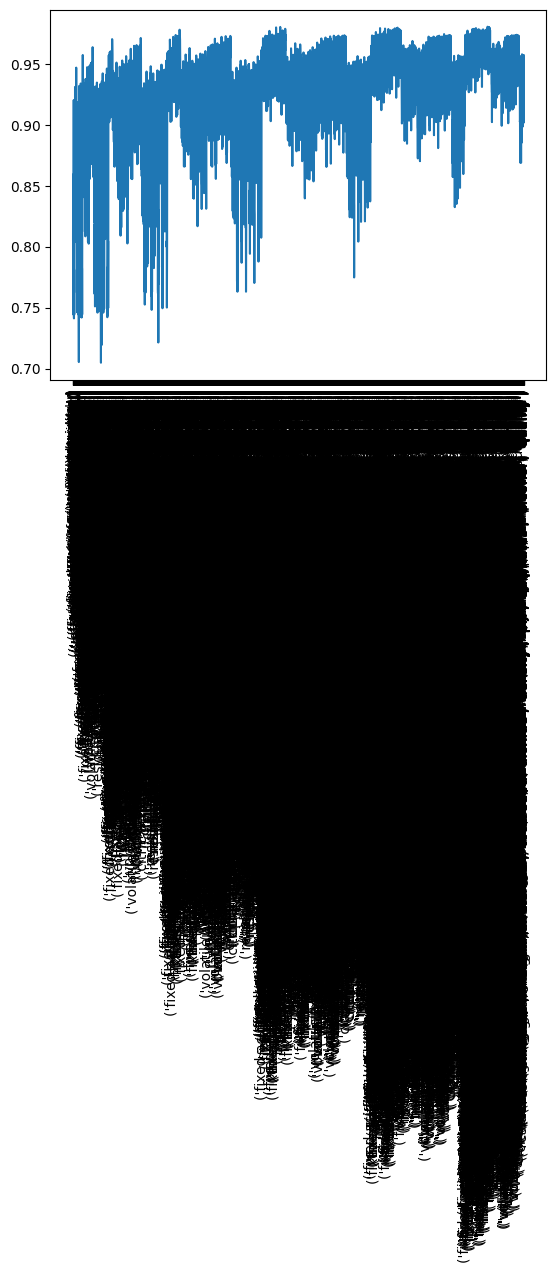

In [45]:
plt.plot([str(k) for k in metric_df['feature_names']], metric_df['avg_score'])
plt.xticks(rotation=90)
plt.show()

Don't know how to plot this much features. 

### Forward selection

In [13]:
X.shape

(5295, 12)

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)   # white=0, red=1


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
print(X_train.shape)
print(X_test.shape)

(4236, 12)
(1059, 12)


In [ ]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train = std.fit_transform(X_train)
X_test = std.transform(X_test)


In [26]:
lr = LogisticRegression()

In [19]:
print("training", np.mean(cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')))
print("training", np.mean(cross_val_score(lr, X_test, y_test, cv=5, scoring='r2')))

training nan
training nan


/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 166, in __call__
    score = scorer._score(
        cached_call, estimator, *args, **routed_params.get(name).score
    )
  File "/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/metrics/_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/metrics/_reg

In [20]:
X_train.shape

(4236, 12)

In [27]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
import numpy as np

# encode target
le = LabelEncoder()
y = le.fit_transform(y)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# model
lr = LogisticRegression(max_iter=1000)

# CV on TRAIN only
cv_score = np.mean(
    cross_val_score(lr, X_train, y_train, cv=3, scoring='accuracy')
)

print("CV accuracy (train):", cv_score)

# final test score
lr.fit(X_train, y_train)
print("Test accuracy:", lr.score(X_test, y_test))


CV accuracy (train): 0.9926817752596789
Test accuracy: 0.9915014164305949


In [28]:
lr = LinearRegression()

exh = EFS(lr, max_features=12, scoring='r2', cv=10, print_progress=True)

sel = exh.fit(X_train, y_train)

Features: 4095/4095

In [29]:
sel.best_score_

np.float64(0.8531067534230756)

In [30]:
sel.best_feature_names_

('0', '1', '2', '3', '4', '5', '6', '7', '9', '10', '11')

In [31]:
sel.best_idx_

(0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11)

In [32]:
metric_df = pd.DataFrame.from_dict(sel.get_metric_dict()).T
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
0,"(0,)","[0.2959339627455012, 0.21173976280062468, 0.26...",0.234193,"(0,)",0.029818,0.040148,0.013383
1,"(1,)","[0.44503440406741446, 0.417194846639521, 0.418...",0.426785,"(1,)",0.020749,0.027936,0.009312
2,"(2,)","[0.03779442420452672, 0.039910770012865804, 0....",0.03697,"(2,)",0.012089,0.016277,0.005426
3,"(3,)","[0.10990697990511322, 0.10980078532414583, 0.1...",0.107675,"(3,)",0.01257,0.016924,0.005641
4,"(4,)","[0.3088585772721274, 0.3042418301594032, 0.272...",0.254677,"(4,)",0.0376,0.050625,0.016875
...,...,...,...,...,...,...,...
4090,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8325462865134751, 0.8334864633486947, 0.833...",0.813158,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11)",0.020862,0.028088,0.009363
4091,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8808656116164717, 0.8712424531778611, 0.871...",0.8504,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.042648,0.057422,0.019141
4092,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8703486833335421, 0.859833614644887, 0.8623...",0.832679,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.050585,0.068108,0.022703
4093,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8766444308862567, 0.8702540252682573, 0.870...",0.852204,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.028341,0.038159,0.01272


In [33]:
def adjust_r2(r2, num_examples, num_features): 
    coef = (num_examples - 1) / (num_examples - num_features - 1)
    return 1 - (1 - r2) * coef

In [34]:
X_train.shape

(4236, 12)

In [35]:
metric_df['observations'] = 4236
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x:len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

In [36]:
metric_df

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err,observations,num_features,adjusted_r2
0,"(0,)","[0.2959339627455012, 0.21173976280062468, 0.26...",0.234193,"(0,)",0.029818,0.040148,0.013383,4236,1,0.234012
1,"(1,)","[0.44503440406741446, 0.417194846639521, 0.418...",0.426785,"(1,)",0.020749,0.027936,0.009312,4236,1,0.42665
2,"(2,)","[0.03779442420452672, 0.039910770012865804, 0....",0.03697,"(2,)",0.012089,0.016277,0.005426,4236,1,0.036742
3,"(3,)","[0.10990697990511322, 0.10980078532414583, 0.1...",0.107675,"(3,)",0.01257,0.016924,0.005641,4236,1,0.107464
4,"(4,)","[0.3088585772721274, 0.3042418301594032, 0.272...",0.254677,"(4,)",0.0376,0.050625,0.016875,4236,1,0.254501
...,...,...,...,...,...,...,...,...,...,...
4090,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8325462865134751, 0.8334864633486947, 0.833...",0.813158,"(0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11)",0.020862,0.028088,0.009363,4236,11,0.812672
4091,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8808656116164717, 0.8712424531778611, 0.871...",0.8504,"(0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.042648,0.057422,0.019141,4236,11,0.85001
4092,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8703486833335421, 0.859833614644887, 0.8623...",0.832679,"(0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.050585,0.068108,0.022703,4236,11,0.832243
4093,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)","[0.8766444308862567, 0.8702540252682573, 0.870...",0.852204,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)",0.028341,0.038159,0.01272,4236,11,0.851819


In [37]:
X_train_sel = sel.transform(X_train)
X_test_sel = sel.transform(X_test)

In [38]:
model = LogisticRegression()

print("training",np.mean(cross_val_score(model, X_train_sel, y_train, cv=5, scoring='r2')))
print("testing",np.mean(cross_val_score(model, X_test_sel, y_test, cv=5, scoring='r2')))

training 0.9614226607766307
testing 0.9410688462280818


### Backward Elimation

In [39]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [40]:
print(X_train.shape)
print(X_test.shape)

(4236, 12)
(1059, 12)


In [42]:
lr = LogisticRegression()

# perform backward elimination
sfs = SFS(lr, k_features='best', forward=True, floating=False, scoring='accuracy',cv=5)

sfs.fit(X_train, y_train)

,estimator,LogisticRegression()
,k_features,"(1, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [43]:
sfs.k_feature_idx_

(1, 2, 3, 5, 6, 7, 10, 11)

In [44]:
metric_df['observations'] = 4236
metric_df['num_features'] = metric_df['feature_idx'].apply(lambda x:len(x))
metric_df['adjusted_r2'] = adjust_r2(metric_df['avg_score'],metric_df['observations'],metric_df['num_features'])

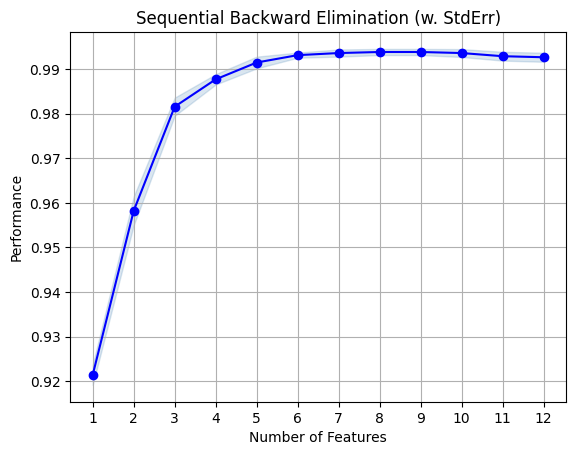

In [45]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_err',)

plt.title('Sequential Backward Elimination (w. StdErr)')
plt.grid()
plt.show()